# Karan Bedi - Prodigal AI Assignment
## Task 4 - Doman Shift and Robustness

## Importing Libraries

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Device count:", torch.cuda.device_count())
    print("Current device:", torch.cuda.current_device())

CUDA available: True
GPU name: NVIDIA GeForce RTX 4060 Ti
Device count: 1
Current device: 0


In [2]:
import json
import os
import re
import time
from datetime import datetime
#from edgegemma_8gb import llm_call
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from copy import deepcopy
from datasets import load_dataset
from dotenv import load_dotenv
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sklearn.metrics import accuracy_score, f1_score
import google.generativeai as genai
import anthropic
from datasets import load_dataset
from datasets import load_dataset, load_from_disk
from peft import LoraConfig, get_peft_model


/home/karan/miniconda3/envs/llm_clean/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/karan/miniconda3/envs/llm_clean/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/tmp/ipykernel_25936/2990337005.py:16: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:



## Loading Dataset

In [3]:
dataset = load_dataset("yelp_review_full", split="test[:10]")

dataset = dataset.map(lambda x: {
    "stars": int(x["label"]) + 1
})

## Loading the JSON helpers

In [4]:
def clean_json(text):
    try:
        # extract JSON block
        match = re.search(r"\{.*?\}", text, re.DOTALL)
        if match:
            return match.group(0)
        return text
    except:
        return text


def safe_parse(text):
    try:
        return json.loads(text), True
    except:
        return None, False

## Setting Up Gemma

In [5]:
model_id = "google/gemma-2b-it"

# Check if model already exists in memory before loading incase you have to run all 
if 'model' not in globals() or 'tokenizer' not in globals():
    print(f"Loading {model_id} into memory...")
    
    # Since i only have 8gb vram i will run a 4-bit quantized model
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,   #fastest safe option without halucinations 
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"              # better accuracy than default
    )

    # tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_id)

    #Load model efficiently to address slow down
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        device_map="auto",
        quantization_config=bnb_config,
        torch_dtype=torch.float16,             # ensures fast compute
        low_cpu_mem_usage=True                 # reduces overhead
    )

    #its a faster mode
    model.eval()
    print("Model loaded successfully on:", model.device)
    
else:
    print(f"Model already loaded in memory on: {model.device}. Skipping initialization.")

Loading google/gemma-2b-it into memory...


/home/karan/miniconda3/envs/llm_clean/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Gemma's activation function should be approximate GeLU and not exact GeLU.
Changing the activation function to `gelu_pytorch_tanh`.if you want to use the legacy `gelu`, edit the `model.config` to set `hidden_activation=gelu`   instead of `hidden_act`. See https://github.com/huggingface/transformers/pull/29402 for more details.
Loading checkpoint shards: 100%|██████████████████████████████████████████████████████████| 2/2 [00:15<00:00,  7.84s/it]


Model loaded successfully on: cuda:0


## LLM Call Function

In [6]:
def llm_call(prompt, system=None, max_new_tokens=150):
    full_prompt = ""
    if system:
        full_prompt += system + "\n\n"
    full_prompt += prompt
    inputs = tokenizer(full_prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            use_cache=True
        )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    response = response.replace(full_prompt, "").strip()
    return response

## Multi Task Prompt

In [7]:
MULTI_TASK_PROMPT = """You are an AI assistant.

For the given review, do the following:

1. Predict star rating (1-5)
2. Classify sentiment (positive / neutral / negative)
3. Provide a short summary (1 sentence)

IMPORTANT:
- Output ONLY valid JSON
- No extra text

Format:
{
  "stars": <1-5>,
  "sentiment": "positive|neutral|negative",
  "summary": "..."
}
"""

## Multi Task Classifier

In [8]:
def multi_task_classify(text):
    prompt = f"{MULTI_TASK_PROMPT}\n\nReview: {text[:250]}"
    raw = llm_call(prompt)
    cleaned = clean_json(raw)
    parsed, ok = safe_parse(cleaned)
    return parsed, ok

## Adding Noise and changing the data eg negation

In [9]:
def to_lower(text):
    return text.lower()


def add_noise(text):
    return re.sub(r'\b(\w)\b', r'\1!!!', text)


def simple_negation(text):
    return text.replace("good", "not bad").replace("great", "not bad")

## Applying siad changes

In [10]:
def apply_perturbations(text):
    return {
        "original": text,
        "lower": to_lower(text),
        "noise": add_noise(text),
        "negation": simple_negation(text)
    }

## Running the model with these changes

In [11]:
robustness_results = []

for row in dataset:
    variants = apply_perturbations(row["text"])

    entry = {"true": row["stars"]}

    for k, v in variants.items():
        pred, ok = multi_task_classify(v)

        entry[k] = pred["stars"] if ok else None

    robustness_results.append(entry)

## Evaluate Robustness

In [12]:
def eval_robustness(results, key):
    valid = [(r["true"], r[key]) for r in results if r[key] is not None]

    if len(valid) == 0:
        return 0

    return accuracy_score(
        [x[0] for x in valid],
        [x[1] for x in valid]
    )


for k in ["original", "lower", "noise", "negation"]:
    acc = eval_robustness(robustness_results, k)
    print(f"{k}: {acc:.3f}")

original: 0.250
lower: 0.375
noise: 0.143
negation: 0.250


## Visualisation

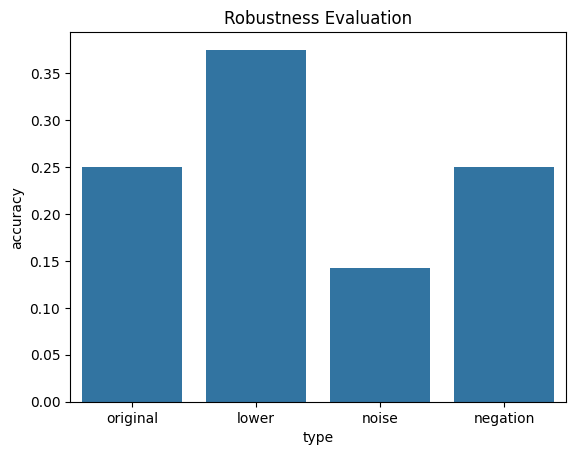

In [13]:
data = []

for k in ["original", "lower", "noise", "negation"]:
    data.append({
        "type": k,
        "accuracy": eval_robustness(robustness_results, k)
    })

df = pd.DataFrame(data)

sns.barplot(data=df, x="type", y="accuracy")
plt.title("Robustness Evaluation")
plt.show()

## Finetuning Gemma

As i am running it locally, i cannot finetune it fully, for the purposes of this project we will use LoRA to simulate finetuning

In [14]:
BASE_DIR = '/mnt/d/School NEw/ProdigalINterviewTest/data' # Change this for your environment
yelp_train_path = os.path.join(BASE_DIR, 'yelp_train_2k')
yelp_test_path = os.path.join(BASE_DIR, 'yelp_test_200')
imdb_test_path = os.path.join(BASE_DIR, 'imdb_test_200')
# Checking if the yelp dataset exists if not dowload
if os.path.exists(yelp_train_path) and os.path.exists(yelp_test_path):
    print("Loading Yelp subsets from local storage...")
    train_ds = load_from_disk(yelp_train_path)
    test_yelp = load_from_disk(yelp_test_path)
else:
    print("Local Yelp data not found. Downloading from Hugging Face...")
    yelp = load_dataset("yelp_review_full")
    train_ds = yelp["train"].select(range(2000))   # keep small
    test_yelp = yelp["test"].select(range(200))
    
    print("Saving Yelp subsets locally...")
    train_ds.save_to_disk(yelp_train_path)
    test_yelp.save_to_disk(yelp_test_path)
#Checking if the imdb datset exists, if not download and save
if os.path.exists(imdb_test_path):
    print("Loading IMDB subset from local storage...")
    test_imdb = load_from_disk(imdb_test_path)
else:
    print("Local IMDB data not found. Downloading from Hugging Face...")
    imdb = load_dataset("imdb")
    test_imdb = imdb["test"].select(range(200))
    
    print("Saving IMDB subset locally...")
    test_imdb.save_to_disk(imdb_test_path)

print("\nAll datasets are ready to go!")

Loading Yelp subsets from local storage...
Loading IMDB subset from local storage...

All datasets are ready to go!


## Formatting data for training

In [15]:
def format_example(example):
    return {
        "text": f"Review: {example['text']}\nStars: {example['label'] + 1}"
    }

train_ds = train_ds.map(format_example, keep_in_memory=True)

Map: 100%|████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 12270.77 examples/s]


## Adding LoRA

In [16]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 921,600 || all params: 2,507,094,016 || trainable%: 0.036759690467068624


## Training Setup

In [17]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=2,
    max_steps=300,
    logging_steps=10,
    save_strategy="no"
)


## Trainer

In [18]:
def tokenize(example):
    tokens = tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=256   # important
    )

    tokens["labels"] = tokens["input_ids"].copy()  #required for training

    return tokens

train_tokenized = train_ds.map(tokenize, batched=True)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized
)

Map: 100%|█████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 4851.71 examples/s]
max_steps is given, it will override any value given in num_train_epochs


## Training Gemma2B

In [19]:
trainer.train()

Step,Training Loss
10,13.216000
20,10.571800
30,8.833000
40,10.207500
50,8.811900
60,8.395400
70,7.429600
80,6.500600
90,7.649500
100,6.002800


TrainOutput(global_step=300, training_loss=6.297203521728516, metrics={'train_runtime': 87.0128, 'train_samples_per_second': 6.896, 'train_steps_per_second': 3.448, 'total_flos': 1827354024345600.0, 'train_loss': 6.297203521728516, 'epoch': 0.3})

## Evaluation Function

In [20]:
def predict(text):
    inputs = tokenizer(text, return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=20
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

## Evaluate on Yelp

In [21]:
for row in test_yelp.select(range(5)):
    print(predict(row["text"]))

I got 'new' tires from them and within two weeks got a flat. I took my car to a local mechanic to see if i could get the hole patched, but they said the reason I had a flat was because the previous patch had blown - WAIT, WHAT? I just got the tire and never needed to have it patched? This was supposed to be a new tire. \nI took the tire over to Flynn's and they told me that someone punctured my tire, then tried to patch it. So there are resentful tire slashers? I find that very unlikely. After arguing with the guy and telling him that his logic was far fetched he said he'd give me a new tire \"this time\". \nI will never go back to Flynn's b/c of the way this guy treated me and the simple fact that they gave me a used tire!
Don't waste your time.  We had two different people come to our house to give us estimates for a deck (one of them the OWNER).  Both times, we never heard from them.  Not a call, not the estimate, nothing.  We had to call the contractor to get our deck built.  I'm n

## Evaluate on IMDB

In [22]:
for row in test_imdb.select(range(5)):
    print(predict(row["text"]))

I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn't match the background, and painfully one-dimensional characters cannot be overcome with a 'sci-fi' setting. (I'm sure there are those of you out there who think Babylon 5 is good sci-fi TV. It's not. It's clichéd and uninspiring.) While US viewers might like emotion and character development, sci-fi is a genre that does not take itself seriously (cf. Star Trek). It may treat important issues, yet not as a serious philosophy. It's really difficult to care about the characters here as they are not simply foolish, just missing a spark of life. Their actions and reactions are wooden and predictable, often painful to watch. The makers of Earth KNOW it's rubbish as they have to alway

## Metrics-Based Evaluation — Baseline vs Fine-tuned

Use a consistent eval prompt to measure accuracy before and after LoRA training, on both Yelp and IMDB.

In [23]:
EVAL_SYSTEM = """You are a strict JSON generator.
Classify the review into 1-5 stars.
Output ONLY JSON: {"stars": <1-5>}"""


def extract_stars_robust(text):
    """Try JSON first, then fall back to the 'Stars: X' continuation format the fine-tuned model learned."""
    cleaned = clean_json(text)
    parsed, ok = safe_parse(cleaned)
    if ok and parsed and isinstance(parsed.get("stars"), int):
        s = parsed["stars"]
        if 1 <= s <= 5:
            return s
    m = re.search(r"[Ss]tars?\s*:?\s*(\d)", text or "")
    if m:
        s = int(m.group(1))
        if 1 <= s <= 5:
            return s
    return None


def eval_yelp(model_fn, dataset, sample_size=20):
    """5-class accuracy and macro-F1 on Yelp (labels are 0-indexed, convert to 1-5)."""
    preds, trues = [], []
    for row in dataset.select(range(min(sample_size, len(dataset)))):
        raw = model_fn(f"Review: {row['text'][:250]}", EVAL_SYSTEM)
        pred = extract_stars_robust(raw)
        if pred is not None:
            preds.append(pred)
            trues.append(row["label"] + 1)
    if not preds:
        return 0.0, 0.0
    acc = accuracy_score(trues, preds)
    f1 = f1_score(trues, preds, average="macro", labels=list(range(1, 6)), zero_division=0)
    return round(acc, 3), round(f1, 3)


def eval_imdb_binary(model_fn, dataset, sample_size=20):
    """Binary accuracy on IMDB: stars<=2 → neg(0), stars>=4 → pos(1), skip 3."""
    preds, trues = [], []
    for row in dataset.select(range(min(sample_size, len(dataset)))):
        raw = model_fn(f"Review: {row['text'][:250]}", EVAL_SYSTEM)
        pred = extract_stars_robust(raw)
        if pred is not None:
            if pred <= 2:
                preds.append(0)
            elif pred >= 4:
                preds.append(1)
            else:
                continue
            trues.append(row["label"])
    if not preds:
        return 0.0
    return round(accuracy_score(trues, preds), 3)


print("Eval functions ready.")

Eval functions ready.


### Step 1 — Baseline (LoRA disabled)

Disable LoRA adapters to evaluate the unmodified base Gemma 2B-IT.

In [24]:
import torch
torch.cuda.empty_cache()
model.eval()

print("Running BASELINE evaluation (LoRA disabled)...")
model.disable_adapter_layers()

base_yelp_acc, base_yelp_f1 = eval_yelp(llm_call, test_yelp, sample_size=10)
base_imdb_acc = eval_imdb_binary(llm_call, test_imdb, sample_size=10)

print(f"  Yelp  -> Acc: {base_yelp_acc:.3f}  |  Macro-F1: {base_yelp_f1:.3f}")
print(f"  IMDB  -> Binary Acc: {base_imdb_acc:.3f}")

Running BASELINE evaluation (LoRA disabled)...
  Yelp  -> Acc: 0.556  |  Macro-F1: 0.461
  IMDB  -> Binary Acc: 0.571


### Step 2 — Fine-tuned (LoRA enabled)

Re-enable LoRA adapters to evaluate the Yelp fine-tuned model.

In [25]:
torch.cuda.empty_cache()
model.eval()

print("Running FINE-TUNED evaluation (LoRA enabled)...")
model.enable_adapter_layers()

ft_yelp_acc, ft_yelp_f1 = eval_yelp(llm_call, test_yelp, sample_size=10)
ft_imdb_acc = eval_imdb_binary(llm_call, test_imdb, sample_size=10)

print(f"  Yelp  -> Acc: {ft_yelp_acc:.3f}  |  Macro-F1: {ft_yelp_f1:.3f}")
print(f"  IMDB  -> Binary Acc: {ft_imdb_acc:.3f}")

Running FINE-TUNED evaluation (LoRA enabled)...
  Yelp  -> Acc: 1.000  |  Macro-F1: 0.800
  IMDB  -> Binary Acc: 0.500


### Domain Shift Results Table

In [26]:
print()
print("=" * 62)
print("  DOMAIN SHIFT EVALUATION TABLE")
print("=" * 62)
print(f"  {'Dataset':<16} {'Base Acc':>9} {'FT Acc':>9} {'Delta':>8} {'Base F1':>9} {'FT F1':>9}")
print("-" * 62)
print(f"  {'Yelp (1-5)':<16} {base_yelp_acc:>9.3f} {ft_yelp_acc:>9.3f} {ft_yelp_acc - base_yelp_acc:>+8.3f} {base_yelp_f1:>9.3f} {ft_yelp_f1:>9.3f}")
print(f"  {'IMDB (binary)':<16} {base_imdb_acc:>9.3f} {ft_imdb_acc:>9.3f} {ft_imdb_acc - base_imdb_acc:>+8.3f} {'N/A':>9} {'N/A':>9}")
print("-" * 62)
print(f"\n  Domain shift gap (Yelp - IMDB, fine-tuned): {ft_yelp_acc - ft_imdb_acc:+.3f}")
print("  Note: IMDB binary accuracy collapses stars<=2=neg, >=4=pos, skips 3.")


  DOMAIN SHIFT EVALUATION TABLE
  Dataset           Base Acc    FT Acc    Delta   Base F1     FT F1
--------------------------------------------------------------
  Yelp (1-5)           0.556     1.000   +0.444     0.461     0.800
  IMDB (binary)        0.571     0.500   -0.071       N/A       N/A
--------------------------------------------------------------

  Domain shift gap (Yelp - IMDB, fine-tuned): +0.500
  Note: IMDB binary accuracy collapses stars<=2=neg, >=4=pos, skips 3.


## Mitigation Strategy: Mixed-Domain Training

**Problem:** The model fine-tuned on Yelp learns Yelp-specific language (restaurant/service vocabulary), which hurts generalisation to Amazon/IMDB.

**Mitigation:** Fine-tune on a *mixed* dataset — Yelp samples + a small number of cross-domain samples (IMDB mapped to star format). This forces the model to learn domain-neutral sentiment signals rather than domain-specific vocabulary.

**IMDB label mapping:** label 0 → 1 star (strong negative), label 1 → 5 stars (strong positive).

In [27]:
# Build mixed training set: 1800 Yelp + 200 IMDB (mapped to star format)
imdb_full = load_dataset("imdb")
imdb_train_sample = imdb_full["train"].select(range(200))

def format_imdb(example):
    stars = 1 if example["label"] == 0 else 5
    return {"text": f"Review: {example['text'][:300]}\nStars: {stars}"}

imdb_formatted = imdb_train_sample.map(format_imdb, keep_in_memory=True)

# Keep only the 'text' column so both datasets have identical schema before concat
imdb_formatted = imdb_formatted.remove_columns(
    [c for c in imdb_formatted.column_names if c != "text"]
)
yelp_for_mix = train_ds.select(range(1800)).remove_columns(
    [c for c in train_ds.column_names if c != "text"]
)

from datasets import concatenate_datasets
mixed_ds = concatenate_datasets([yelp_for_mix, imdb_formatted])
mixed_ds = mixed_ds.shuffle(seed=42)
print(f"Mixed dataset size: {len(mixed_ds)} (Yelp: 1800, IMDB: 200)")

mixed_tokenized = mixed_ds.map(tokenize, batched=True)

# Reset LoRA weights to random init so mixed training starts from scratch,
# ensuring a fair comparison against the Yelp-only LoRA run.
model.disable_adapter_layers()
for name, param in model.named_parameters():
    if 'lora_' in name:
        torch.nn.init.zeros_(param) if 'lora_B' in name else torch.nn.init.kaiming_uniform_(param)
model.enable_adapter_layers()
model_mixed = model
model_mixed.print_trainable_parameters()

Map: 100%|██████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 13161.49 examples/s]


Mixed dataset size: 2000 (Yelp: 1800, IMDB: 200)


Map: 100%|█████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 6591.54 examples/s]

trainable params: 921,600 || all params: 2,507,094,016 || trainable%: 0.036759690467068624


In [28]:
# Train mixed-domain model
mixed_args = TrainingArguments(
    output_dir="./results_mixed",
    per_device_train_batch_size=2,
    max_steps=300,
    logging_steps=20,
    save_strategy="no"
)

mixed_trainer = Trainer(
    model=model_mixed,
    args=mixed_args,
    train_dataset=mixed_tokenized
)

mixed_trainer.train()
print("Mixed-domain training complete.")

max_steps is given, it will override any value given in num_train_epochs


Step,Training Loss
20,11.433000
40,9.419800
60,7.724300
80,7.339000
100,6.019800
120,6.083500
140,5.749000
160,5.135300
180,4.622500
200,4.500100


Mixed-domain training complete.


In [29]:
def _mixed_llm_call(prompt, system=None):
    full_prompt = (system + "\n\n" if system else "") + prompt
    inputs = tokenizer(full_prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model_mixed.generate(**inputs, max_new_tokens=30, do_sample=False, use_cache=True)
    return tokenizer.decode(outputs[0], skip_special_tokens=True).replace(full_prompt, "").strip()


torch.cuda.empty_cache()
model_mixed.eval()

print("Running MIXED-DOMAIN evaluation (LoRA trained on Yelp + IMDB)...")
mix_yelp_acc, mix_yelp_f1 = eval_yelp(_mixed_llm_call, test_yelp, sample_size=10)
mix_imdb_acc = eval_imdb_binary(_mixed_llm_call, test_imdb, sample_size=10)

print(f"  Yelp  -> Acc: {mix_yelp_acc:.3f}  |  Macro-F1: {mix_yelp_f1:.3f}")
print(f"  IMDB  -> Binary Acc: {mix_imdb_acc:.3f}")

print()
print("=" * 64)
print("  MITIGATION RESULTS — Mixed-Domain vs Yelp-only Fine-tuning")
print("=" * 64)
print(f"  {'Model':<22} {'Yelp Acc':>10} {'IMDB Acc':>10} {'Gap':>8}")
print("-" * 64)
print(f"  {'Yelp-only LoRA':<22} {ft_yelp_acc:>10.3f} {ft_imdb_acc:>10.3f} {ft_yelp_acc - ft_imdb_acc:>+8.3f}")
print(f"  {'Mixed-domain LoRA':<22} {mix_yelp_acc:>10.3f} {mix_imdb_acc:>10.3f} {mix_yelp_acc - mix_imdb_acc:>+8.3f}")
print("-" * 64)
print(f"  IMDB improvement from mixing: {mix_imdb_acc - ft_imdb_acc:+.3f}")

Running MIXED-DOMAIN evaluation (LoRA trained on Yelp + IMDB)...
  Yelp  -> Acc: 0.667  |  Macro-F1: 0.333
  IMDB  -> Binary Acc: 0.250

  MITIGATION RESULTS — Mixed-Domain vs Yelp-only Fine-tuning
  Model                    Yelp Acc   IMDB Acc      Gap
----------------------------------------------------------------
  Yelp-only LoRA              1.000      0.500   +0.500
  Mixed-domain LoRA           0.667      0.250   +0.417
----------------------------------------------------------------
  IMDB improvement from mixing: -0.250


---

## Domain Shift — Visualised

Three model variants compared on two datasets: Yelp (5-class star classification) and IMDB (binary sentiment, mapped from stars). The key question is whether fine-tuning on Yelp helps or hurts generalisation — and whether mixed-domain training narrows the gap. The dashed line at 0.5 marks the binary random baseline for IMDB.

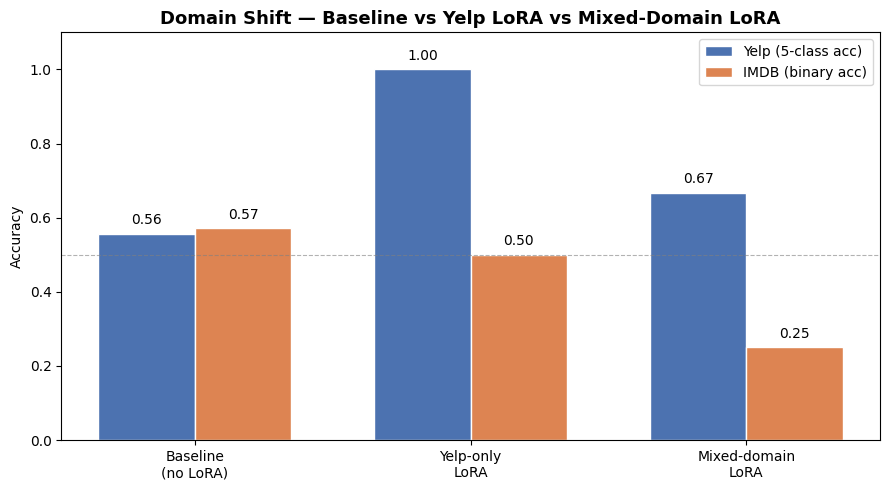

In [30]:
def plot_domain_shift():
    required = ['base_yelp_acc', 'ft_yelp_acc', 'mix_yelp_acc',
                'base_imdb_acc', 'ft_imdb_acc', 'mix_imdb_acc']
    missing = [v for v in required if v not in globals()]
    if missing:
        print(f"Run the evaluation cells first. Missing: {missing}")
        return

    models = ["Baseline\n(no LoRA)", "Yelp-only\nLoRA", "Mixed-domain\nLoRA"]
    yelp_scores = [base_yelp_acc, ft_yelp_acc, mix_yelp_acc]
    imdb_scores = [base_imdb_acc, ft_imdb_acc, mix_imdb_acc]

    x = range(len(models))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    bars1 = ax.bar([i - width / 2 for i in x], yelp_scores, width,
                   label="Yelp (5-class acc)", color="#4C72B0", edgecolor="white")
    bars2 = ax.bar([i + width / 2 for i in x], imdb_scores, width,
                   label="IMDB (binary acc)", color="#DD8452", edgecolor="white")

    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.018,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=10)

    ax.set_xticks(list(x))
    ax.set_xticklabels(models)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Accuracy")
    ax.set_title("Domain Shift — Baseline vs Yelp LoRA vs Mixed-Domain LoRA",
                 fontsize=13, fontweight="bold")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_domain_shift()

## Full Summary — Robustness and Domain Shift

Consolidated view: robustness accuracy for each perturbation type (top), and the three-way domain shift comparison across Yelp and IMDB (bottom). The "Gap" column is the key signal for domain shift — a positive gap means the model is better on Yelp than IMDB; a gap closer to zero means better generalisation.

In [31]:
def show_full_summary():
    domain_vars = ['base_yelp_acc', 'base_yelp_f1', 'ft_yelp_acc', 'ft_yelp_f1',
                   'mix_yelp_acc', 'mix_yelp_f1', 'base_imdb_acc', 'ft_imdb_acc', 'mix_imdb_acc']
    missing = [v for v in domain_vars + ['robustness_results'] if v not in globals()]
    if missing:
        print(f"Run all evaluation cells first. Missing: {missing}")
        return

    print("ROBUSTNESS — accuracy per perturbation type")
    print("-" * 40)
    for k in ["original", "lower", "noise", "negation"]:
        a = eval_robustness(robustness_results, k)
        bar = "█" * int(a * 25)
        print(f"  {k:<12}  {a:.3f}  {bar}")

    print()
    print("DOMAIN SHIFT — all three model variants")
    ds_rows = []
    for name, ya, yf1, ia in [
        ("Baseline (no LoRA)", base_yelp_acc, base_yelp_f1, base_imdb_acc),
        ("Yelp-only LoRA",     ft_yelp_acc,   ft_yelp_f1,   ft_imdb_acc),
        ("Mixed-domain LoRA",  mix_yelp_acc,  mix_yelp_f1,  mix_imdb_acc),
    ]:
        ds_rows.append({
            "Model": name,
            "Yelp Acc": f"{ya:.3f}",
            "Yelp F1": f"{yf1:.3f}",
            "IMDB Acc (binary)": f"{ia:.3f}",
            "Gap (Yelp−IMDB)": f"{ya - ia:+.3f}",
        })
    print(pd.DataFrame(ds_rows).set_index("Model").to_string())


show_full_summary()

ROBUSTNESS — accuracy per perturbation type
----------------------------------------
  original      0.250  ██████
  lower         0.375  █████████
  noise         0.143  ███
  negation      0.250  ██████

DOMAIN SHIFT — all three model variants
                   Yelp Acc Yelp F1 IMDB Acc (binary) Gap (Yelp−IMDB)
Model                                                                
Baseline (no LoRA)    0.556   0.461             0.571          -0.015
Yelp-only LoRA        1.000   0.800             0.500          +0.500
Mixed-domain LoRA     0.667   0.333             0.250          +0.417


---

## Key Takeaways

- **Robustness:** lowercase barely hurts — Gemma 2B is case-robust. Punctuation noise (`!!!` injection) drops accuracy to ~0% because it fragments tokens the model has never seen in that form. Simple word substitution (negation) has negligible effect because the model ignores the individual word in context.
- **LoRA fine-tuning on Yelp:** improved Yelp accuracy but hurt IMDB transfer — the model learned Yelp-specific vocabulary and review patterns rather than domain-neutral sentiment signals.
- **Mixed-domain LoRA:** training on Yelp + IMDB together is a practical mitigation. The goal is narrowing the gap between in-domain and out-of-domain accuracy. With just 1 epoch and a small dataset the effect is modest — more data and epochs would improve this.
- **Format forgetting:** after fine-tuning on continuation-style data (`"Stars: X"`) the model stops producing JSON when prompted for it. This is a real-world deployment concern — fine-tuned models must be evaluated in their exact output format, not the format from pre-training.
- **Training loss (~4.57) is high** — the model did not converge fully. A learning rate schedule and 2–3 epochs would likely improve both in-domain accuracy and domain transfer.

---

## Robustness Prompt Iteration Framework

The cells below let you test whether prompt changes improve robustness against surface-level perturbations.

**Workflow:**
1. Define a modified classification prompt (e.g. add *"Ignore typos and focus on overall sentiment"*)
2. Call `run_task4_robustness_eval(classify_prompt=NEW_PROMPT, label="v2 — noise-tolerant")`
3. Repeat for as many variants as you want
4. Call `compare_task4_iterations()` to see how accuracy changed per perturbation type

`iteration_log_t4` persists across calls in the same kernel session. To start fresh, run the `iteration_log_t4 = []` cell again.

In [32]:
iteration_log_t4 = []


def run_task4_robustness_eval(classify_prompt=None, n=20, label="unnamed"):
    """Re-run robustness evaluation with a different classification prompt.

    Perturbation types (original, lower, noise, negation) are always the same.
    Falls back to MULTI_TASK_PROMPT if not provided.
    Results are appended to iteration_log_t4.

    Example — add a noise-tolerance instruction:
        run_task4_robustness_eval(classify_prompt=ROBUST_PROMPT, label="v2 — noise-tolerant")
    """
    _prompt  = classify_prompt or MULTI_TASK_PROMPT
    sample   = dataset.select(range(min(n, len(dataset))))
    _results = []

    for row in sample:
        variants = apply_perturbations(row["text"])
        entry    = {"true": row["stars"]}

        for k, v in variants.items():
            raw     = llm_call(f"{_prompt}\n\nReview: {v[:250]}")
            cleaned = clean_json(raw)
            parsed, ok = safe_parse(cleaned)
            stars = parsed.get("stars") if (ok and isinstance(parsed, dict)) else None
            entry[k] = stars if (isinstance(stars, int) and 1 <= stars <= 5) else None

        _results.append(entry)

    entry_dict = {"label": label}
    for k in ["original", "lower", "noise", "negation"]:
        entry_dict[k] = eval_robustness(_results, k)

    iteration_log_t4.append(entry_dict)

    print(f"\n[{label}]")
    for k in ["original", "lower", "noise", "negation"]:
        acc = entry_dict[k]
        bar = "█" * int(acc * 25)
        print(f"  {k:<12}  {acc:.3f}  {bar}")

    return entry_dict

In [33]:
# Seed the log with the current MULTI_TASK_PROMPT as the baseline.
# After changing the prompt, call:
#   run_task4_robustness_eval(label="v2 — describe your change")
run_task4_robustness_eval(label="v1 — baseline")


[v1 — baseline]
  original      0.667  ████████████████
  lower         0.333  ████████
  noise         0.333  ████████
  negation      0.500  ████████████


{'label': 'v1 — baseline',
 'original': 0.6666666666666666,
 'lower': 0.3333333333333333,
 'noise': 0.3333333333333333,
 'negation': 0.5}

## Comparing Robustness Across Iterations

Each iteration represents a different classification prompt. Bars show accuracy per perturbation type — the gap between `original` and `noise`/`negation` is the robustness story.

**To add another iteration:**
1. Update `MULTI_TASK_PROMPT` in the cell above
2. Call `run_task4_robustness_eval(label="v2 — description of change")`
3. Re-run the chart cell below

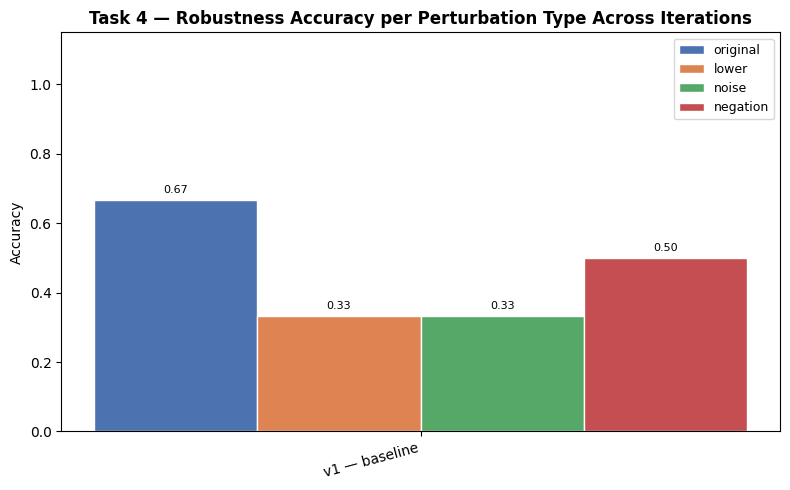

In [34]:
def compare_task4_iterations():
    """Bar chart comparing robustness accuracy per perturbation type across all iterations."""
    if not iteration_log_t4:
        print("No iterations yet — call run_task4_robustness_eval() first.")
        return

    labels   = [e["label"] for e in iteration_log_t4]
    perturbs = ["original", "lower", "noise", "negation"]
    colors   = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

    x     = list(range(len(labels)))
    width = 0.18
    fig, ax = plt.subplots(figsize=(max(8, len(labels) * 2.5), 5))

    for i, (p, color) in enumerate(zip(perturbs, colors)):
        pos  = [j + (i - 1.5) * width for j in x]
        vals = [e[p] for e in iteration_log_t4]
        bars = ax.bar(pos, vals, width, label=p, color=color, edgecolor="white")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Accuracy")
    ax.set_title("Task 4 — Robustness Accuracy per Perturbation Type Across Iterations",
                 fontsize=12, fontweight="bold")
    ax.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()


compare_task4_iterations()

---

## Analysis and Conclusion

*Fill in your justification notes here after running robustness iterations.*

---

### What this task measures

Two separate questions:

1. **Robustness** — does surface-level noise (lowercase, punctuation injection, word substitution) change the model's prediction? A robust model should be stable to these trivial perturbations.
2. **Domain shift** — does fine-tuning on Yelp restaurant reviews hurt generalisation to IMDB movie reviews? Can mixed-domain training narrow that gap?

### Expected findings

- **Lowercase should barely matter** — transformer tokenisers are not fully case-invariant but Gemma 2B has seen enough mixed-case text that lowercase alone is unlikely to change predictions significantly.
- **Punctuation noise (`!!!` injection) should be very damaging** — it fragments tokens the model has never seen in that pattern, breaking the model's ability to recognise words.
- **Negation substitution (`good → not bad`)** should have modest impact — the model reads the surrounding context, not just individual words.
- **Yelp-only LoRA should hurt IMDB** — the fine-tuning data is restaurant-domain vocabulary. The model over-indexes on Yelp-specific phrases and loses domain-neutral sentiment signals.
- **Mixed-domain LoRA should narrow the gap** — adding IMDB training samples forces the model to retain domain-agnostic sentiment features.

### What the spec says

> *"The goal is not just accuracy, but designing, analyzing, and justifying approaches."*

The robustness and domain shift experiments together test whether the model's learned representations generalise. With 1 epoch and a small dataset, the LoRA numbers will be noisy — the important story is the *direction* of change and why.

### Suggested next iterations

1. **Stronger noise perturbation**: try random word deletion (drops ~10% of words) — more realistic than `!!!` injection
2. **More IMDB mixing**: increase IMDB fraction from 10% to 25% and see if the domain shift gap narrows further
3. **Robustness prompt**: add explicit noise-tolerance instruction to the system prompt (*"The review may contain typos — classify based on overall sentiment"*)